In [43]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt

**Step 1: Fetch Data from API**

In [8]:
import os
from dotenv import load_dotenv


file_loaded = load_dotenv()

API_KEY = os.getenv('TMDB_API_KEY') 


In [6]:
URL = "https://api.themoviedb.org/3/movie"

movie_id = [
    0, 299534, 19995, 140607, 299536, 597, 135397,
    420818, 24428, 168259, 99861, 284054, 12445,
    181808, 330457, 351286, 109445, 321612, 260513
]

In [7]:
def fetch_data(ids):
    movies = []
    for mov_id in ids:
        url = f"{URL}/{mov_id}?api_key={API_KEY}"
        response = requests.get(url)

        if response.status_code == 200:
            movies.append(response.json())
        else:
            print(f"Error fetching ID {mov_id}:{response.status_code}")
    return movies

fetch_data(movie_id)

Error fetching ID 0:404


[{'adult': False,
  'backdrop_path': '/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg',
  'belongs_to_collection': {'id': 86311,
   'name': 'The Avengers Collection',
   'poster_path': '/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg',
   'backdrop_path': '/2UNUv4NJdC36E5myDHACBJ99EwL.jpg'},
  'budget': 356000000,
  'genres': [{'id': 12, 'name': 'Adventure'},
   {'id': 878, 'name': 'Science Fiction'},
   {'id': 28, 'name': 'Action'}],
  'homepage': 'https://www.marvel.com/movies/avengers-endgame',
  'id': 299534,
  'imdb_id': 'tt4154796',
  'origin_country': ['US'],
  'original_language': 'en',
  'original_title': 'Avengers: Endgame',
  'overview': "After the devastating events of Avengers: Infinity War, the universe is in ruins due to the efforts of the Mad Titan, Thanos. With the help of remaining allies, the Avengers must assemble once more in order to undo Thanos' actions and restore order to the universe once and for all, no matter what consequences may be in store.",
  'popularity': 13.9572,
  'poster_path': 

**Convert to dataframe**

In [8]:
movies = pd.DataFrame(data=fetch_data(movie_id))
movies

Error fetching ID 0:404


,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,revenue,runtime,softcore,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",356000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 878, ...",https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,...,2799439100,181,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Avenge the fallen.,Avengers: Endgame,False,8.239,28042
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,"{'id': 87096, 'name': 'Avatar Collection', 'po...",237000000,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,...,2923706026,162,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Enter the world of Pandora.,Avatar,False,7.609,34234
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,"{'id': 10, 'name': 'Star Wars Collection', 'po...",245000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,...,2068223624,136,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.248,20661
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",300000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,...,2052415039,149,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.239,32298
4,False,/xnHVX37XZEp33hhCbYlQFq7ux1J.jpg,None,200000000,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,...,2264162353,194,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Nothing on earth could come between them.,Titanic,False,7.902,27361
5,False,/dF6FjTZzRTENfB4R17HDN20jLT2.jpg,"{'id': 328, 'name': 'Jurassic Park Collection'...",150000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 878, ...",https://www.jurassicworld.com/,135397,tt0369610,[US],en,...,1671537444,124,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,The park is open.,Jurassic World,False,6.703,21694
6,False,/1TUg5pO1VZ4B0Q1amk3OlXvlpXV.jpg,"{'id': 762512, 'name': 'The Lion King (Reboot)...",260000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 18, '...",https://movies.disney.com/the-lion-king-2019,420818,tt6105098,[US],en,...,1662020819,118,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,The king has returned.,The Lion King,False,7.096,10800
7,False,/pGFQCp12a8andfPlpnmXz44IIvY.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",220000000,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",https://www.marvel.com/movies/the-avengers,24428,tt0848228,[US],en,...,1518815515,143,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Some assembly required.,The Avengers,False,8.057,38785
8,False,/ehzI1mVcnHqB58NqPyQwpMqcVoz.jpg,"{'id': 9485, 'name': 'The Fast and the Furious...",190000000,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",https://www.universalpicturesathome.com/movies...,168259,tt2820852,[US],en,...,1515400000,138,False,"[{'english_name': 'Arabic', 'iso_639_1': 'ar',...",Released,Vengeance hits home.,Furious 7,False,7.218,11363
9,False,/kIBK5SKwgqIIuRKhhWrJn3XkbPq.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",235000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",https://www.marvel.com/movies/avengers-age-of-...,99861,tt2395427,[US],en,...,1405403694,141,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,A new age has come.,Avengers: Age of Ultron,False,7.275,24611


---

**Step 2: Data Cleaning and Processing**

**1. Drop irrelevant columns**

In [9]:
irrelevant_cols = ['adult', 'imdb_id', 'original_title', 'video', 'homepage']
movies = movies.drop(columns=irrelevant_cols)

In [10]:
movies.columns

Index(['backdrop_path', 'belongs_to_collection', 'budget', 'genres', 'id',
       'origin_country', 'original_language', 'overview', 'popularity',
       'poster_path', 'production_companies', 'production_countries',
       'release_date', 'revenue', 'runtime', 'softcore', 'spoken_languages',
       'status', 'tagline', 'title', 'vote_average', 'vote_count'],
      dtype='str')

2.Evaluate JSON-like columns: ['belongs_to_collection', 'genres', 'production_countries', 'production_companies', 'spoken_languages']

In [11]:
def clean_json_list(item):
    if isinstance(item, list):
        return "|".join([i['name'] for i in item if 'name' in i])
    if isinstance(item, dict):
        return item.get('name', np.nan)
    return np.nan

movies['genres'] = movies['genres'].apply(clean_json_list)
movies['spoken_languages'] = movies['spoken_languages'].apply(clean_json_list)
movies['production_countries'] = movies['production_countries'].apply(clean_json_list)
movies['production_companies'] = movies['production_companies'].apply(clean_json_list)
movies['belongs_to_collection'] = movies['belongs_to_collection'].apply(clean_json_list)


In [14]:
movies

,backdrop_path,belongs_to_collection,budget,genres,id,origin_country,original_language,overview,popularity,poster_path,...,release_date,revenue,runtime,softcore,spoken_languages,status,tagline,title,vote_average,vote_count
0,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,The Avengers Collection,356000000,Adventure|Science Fiction|Action,299534,[US],en,After the devastating events of Avengers: Infi...,13.9572,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,...,2019-04-24,2799439100,181,False,English|日本語|,Released,Avenge the fallen.,Avengers: Endgame,8.239,28042
1,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,Avatar Collection,237000000,Science Fiction|Action|Adventure,19995,[US],en,"In the 22nd century, a paraplegic Marine is di...",15.0060,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,...,2009-12-16,2923706026,162,False,English|Español,Released,Enter the world of Pandora.,Avatar,7.609,34234
2,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,Star Wars Collection,245000000,Adventure|Action|Science Fiction,140607,[US],en,Thirty years after defeating the Galactic Empi...,6.8790,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,...,2015-12-15,2068223624,136,False,English,Released,Every generation has a story.,Star Wars: The Force Awakens,7.248,20661
3,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,The Avengers Collection,300000000,Adventure|Action|Science Fiction,299536,[US],en,As the Avengers and their allies have continue...,22.6013,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,...,2018-04-25,2052415039,149,False,English|,Released,Destiny arrives all the same.,Avengers: Infinity War,8.239,32298
4,/xnHVX37XZEp33hhCbYlQFq7ux1J.jpg,NaN,200000000,Drama|Romance,597,[US],en,101-year-old Rose DeWitt Bukater tells the sto...,15.8007,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,...,1997-12-18,2264162353,194,False,English|Français|Deutsch|svenska|Italiano|Pусский,Released,Nothing on earth could come between them.,Titanic,7.902,27361
5,/dF6FjTZzRTENfB4R17HDN20jLT2.jpg,Jurassic Park Collection,150000000,Adventure|Science Fiction|Thriller,135397,[US],en,Twenty-two years after the events of Jurassic ...,16.9054,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,...,2015-06-06,1671537444,124,False,English,Released,The park is open.,Jurassic World,6.703,21694
6,/1TUg5pO1VZ4B0Q1amk3OlXvlpXV.jpg,The Lion King (Reboot) Collection,260000000,Adventure|Drama|Family|Animation,420818,[US],en,"Simba idolizes his father, King Mufasa, and ta...",11.8006,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,...,2019-07-12,1662020819,118,False,English,Released,The king has returned.,The Lion King,7.096,10800
7,/pGFQCp12a8andfPlpnmXz44IIvY.jpg,The Avengers Collection,220000000,Science Fiction|Action|Adventure,24428,[US],en,When an unexpected enemy emerges and threatens...,27.1498,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,...,2012-04-25,1518815515,143,False,English|हिन्दी|Pусский,Released,Some assembly required.,The Avengers,8.057,38785
8,/ehzI1mVcnHqB58NqPyQwpMqcVoz.jpg,The Fast and the Furious Collection,190000000,Action|Crime|Thriller,168259,[US],en,Deckard Shaw seeks revenge against Dominic Tor...,9.5689,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,...,2015-04-01,1515400000,138,False,العربية|English|Español|ภาษาไทย,Released,Vengeance hits home.,Furious 7,7.218,11363
9,/kIBK5SKwgqIIuRKhhWrJn3XkbPq.jpg,The Avengers Collection,235000000,Action|Adventure|Science Fiction,99861,[US],en,When Tony Stark tries to jumpstart a dormant p...,20.3748,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,...,2015-04-22,1405403694,141,False,English,Released,A new age has come.,Avengers: Age of Ultron,7.275,24611


#### **Handling missing & Incorrect Data** 

**5. Convert Column datatypes:**

In [15]:
movies.dtypes

backdrop_path                str
belongs_to_collection        str
budget                     int64
genres                       str
id                         int64
origin_country            object
original_language            str
overview                     str
popularity               float64
poster_path                  str
production_companies         str
production_countries         str
release_date                 str
revenue                    int64
runtime                    int64
softcore                    bool
spoken_languages             str
status                       str
tagline                      str
title                        str
vote_average             float64
vote_count                 int64
dtype: object

In [17]:
movies["budget"] = pd.to_numeric(movies['budget'])
movies["id"] = pd.to_numeric(movies['id'])
movies["popularity"] = pd.to_numeric(movies['popularity'])
movies['release_date'] = pd.to_datetime(movies['release_date'])

In [18]:
movies.dtypes

backdrop_path                       str
belongs_to_collection               str
budget                            int64
genres                              str
id                                int64
origin_country                   object
original_language                   str
overview                            str
popularity                      float64
poster_path                         str
production_companies                str
production_countries                str
release_date             datetime64[us]
revenue                           int64
runtime                           int64
softcore                           bool
spoken_languages                    str
status                              str
tagline                             str
title                               str
vote_average                    float64
vote_count                        int64
dtype: object

**6. Replace unrealistic values**

In [56]:
movies[movies['budget'] == 0]

,backdrop_path,belongs_to_collection,budget,genres,id,origin_country,original_language,overview,popularity,poster_path,...,release_date,revenue,runtime,softcore,spoken_languages,status,tagline,title,vote_average,vote_count


In [20]:
for col in ['budget', 'revenue', 'runtime']:
       movies[col] = movies[col].replace(0, np.nan)

In [ ]:
# Convert bugdet and revenue to million USD

movies['budget_musd'] = movies['budget'] / 1_000_000
movies['revenue_musd'] = movies['revenue'] / 1_000_000

In [23]:
movies

,backdrop_path,belongs_to_collection,budget,genres,id,origin_country,original_language,overview,popularity,poster_path,...,runtime,softcore,spoken_languages,status,tagline,title,vote_average,vote_count,budget_musd,revenue_musd
0,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,The Avengers Collection,356000000,Adventure|Science Fiction|Action,299534,[US],en,After the devastating events of Avengers: Infi...,13.9572,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,...,181,False,English|日本語|,Released,Avenge the fallen.,Avengers: Endgame,8.239,28042,356.0,2799.439100
1,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,Avatar Collection,237000000,Science Fiction|Action|Adventure,19995,[US],en,"In the 22nd century, a paraplegic Marine is di...",15.0060,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,...,162,False,English|Español,Released,Enter the world of Pandora.,Avatar,7.609,34234,237.0,2923.706026
2,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,Star Wars Collection,245000000,Adventure|Action|Science Fiction,140607,[US],en,Thirty years after defeating the Galactic Empi...,6.8790,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,...,136,False,English,Released,Every generation has a story.,Star Wars: The Force Awakens,7.248,20661,245.0,2068.223624
3,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,The Avengers Collection,300000000,Adventure|Action|Science Fiction,299536,[US],en,As the Avengers and their allies have continue...,22.6013,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,...,149,False,English|,Released,Destiny arrives all the same.,Avengers: Infinity War,8.239,32298,300.0,2052.415039
4,/xnHVX37XZEp33hhCbYlQFq7ux1J.jpg,NaN,200000000,Drama|Romance,597,[US],en,101-year-old Rose DeWitt Bukater tells the sto...,15.8007,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,...,194,False,English|Français|Deutsch|svenska|Italiano|Pусский,Released,Nothing on earth could come between them.,Titanic,7.902,27361,200.0,2264.162353
5,/dF6FjTZzRTENfB4R17HDN20jLT2.jpg,Jurassic Park Collection,150000000,Adventure|Science Fiction|Thriller,135397,[US],en,Twenty-two years after the events of Jurassic ...,16.9054,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,...,124,False,English,Released,The park is open.,Jurassic World,6.703,21694,150.0,1671.537444
6,/1TUg5pO1VZ4B0Q1amk3OlXvlpXV.jpg,The Lion King (Reboot) Collection,260000000,Adventure|Drama|Family|Animation,420818,[US],en,"Simba idolizes his father, King Mufasa, and ta...",11.8006,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,...,118,False,English,Released,The king has returned.,The Lion King,7.096,10800,260.0,1662.020819
7,/pGFQCp12a8andfPlpnmXz44IIvY.jpg,The Avengers Collection,220000000,Science Fiction|Action|Adventure,24428,[US],en,When an unexpected enemy emerges and threatens...,27.1498,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,...,143,False,English|हिन्दी|Pусский,Released,Some assembly required.,The Avengers,8.057,38785,220.0,1518.815515
8,/ehzI1mVcnHqB58NqPyQwpMqcVoz.jpg,The Fast and the Furious Collection,190000000,Action|Crime|Thriller,168259,[US],en,Deckard Shaw seeks revenge against Dominic Tor...,9.5689,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,...,138,False,العربية|English|Español|ภาษาไทย,Released,Vengeance hits home.,Furious 7,7.218,11363,190.0,1515.400000
9,/kIBK5SKwgqIIuRKhhWrJn3XkbPq.jpg,The Avengers Collection,235000000,Action|Adventure|Science Fiction,99861,[US],en,When Tony Stark tries to jumpstart a dormant p...,20.3748,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,...,141,False,English,Released,A new age has come.,Avengers: Age of Ultron,7.275,24611,235.0,1405.403694


In [25]:
movies.loc[movies['vote_count'] == 0, 'vote_average'] = np.nan
movies['overview'].replace('No Data', np.nan, inplace=True)
movies['tagline'].replace('No Data', np.nan, inplace=True)

/tmp/ipykernel_22904/2290435162.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  movies['overview'].replace('No Data', np.nan, inplace=True)
/tmp/ipykernel_22904/2290435162.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method n

0                                    Avenge the fallen.
1                           Enter the world of Pandora.
2                         Every generation has a story.
3                         Destiny arrives all the same.
4             Nothing on earth could come between them.
5                                     The park is open.
6                                The king has returned.
7                               Some assembly required.
8                                  Vengeance hits home.
9                                   A new age has come.
10                                  Long live the king.
11                                         It all ends.
12                                    Let the past die.
13                       The past is not what it seems.
14                                    The park is gone.
15    Who will save the day? The ice guy? The nice g...
16                                        Be our guest.
17                        It's been too long, da

**7. Remove duplicates and drop rows with unknow id or title**

In [28]:
movies.drop_duplicates(subset=['id', 'title'], inplace=True)
movies.dropna(subset=['id', 'title'], inplace=True)

**Keep only rows where at least 10 columns have non-NaN values**

In [30]:
movies = movies[movies.notna().sum(axis=1) >= 10]

In [31]:
movies

,backdrop_path,belongs_to_collection,budget,genres,id,origin_country,original_language,overview,popularity,poster_path,...,runtime,softcore,spoken_languages,status,tagline,title,vote_average,vote_count,budget_musd,revenue_musd
0,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,The Avengers Collection,356000000,Adventure|Science Fiction|Action,299534,[US],en,After the devastating events of Avengers: Infi...,13.9572,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,...,181,False,English|日本語|,Released,Avenge the fallen.,Avengers: Endgame,8.239,28042,356.0,2799.439100
1,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,Avatar Collection,237000000,Science Fiction|Action|Adventure,19995,[US],en,"In the 22nd century, a paraplegic Marine is di...",15.0060,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,...,162,False,English|Español,Released,Enter the world of Pandora.,Avatar,7.609,34234,237.0,2923.706026
2,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,Star Wars Collection,245000000,Adventure|Action|Science Fiction,140607,[US],en,Thirty years after defeating the Galactic Empi...,6.8790,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,...,136,False,English,Released,Every generation has a story.,Star Wars: The Force Awakens,7.248,20661,245.0,2068.223624
3,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,The Avengers Collection,300000000,Adventure|Action|Science Fiction,299536,[US],en,As the Avengers and their allies have continue...,22.6013,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,...,149,False,English|,Released,Destiny arrives all the same.,Avengers: Infinity War,8.239,32298,300.0,2052.415039
4,/xnHVX37XZEp33hhCbYlQFq7ux1J.jpg,NaN,200000000,Drama|Romance,597,[US],en,101-year-old Rose DeWitt Bukater tells the sto...,15.8007,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,...,194,False,English|Français|Deutsch|svenska|Italiano|Pусский,Released,Nothing on earth could come between them.,Titanic,7.902,27361,200.0,2264.162353
5,/dF6FjTZzRTENfB4R17HDN20jLT2.jpg,Jurassic Park Collection,150000000,Adventure|Science Fiction|Thriller,135397,[US],en,Twenty-two years after the events of Jurassic ...,16.9054,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,...,124,False,English,Released,The park is open.,Jurassic World,6.703,21694,150.0,1671.537444
6,/1TUg5pO1VZ4B0Q1amk3OlXvlpXV.jpg,The Lion King (Reboot) Collection,260000000,Adventure|Drama|Family|Animation,420818,[US],en,"Simba idolizes his father, King Mufasa, and ta...",11.8006,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,...,118,False,English,Released,The king has returned.,The Lion King,7.096,10800,260.0,1662.020819
7,/pGFQCp12a8andfPlpnmXz44IIvY.jpg,The Avengers Collection,220000000,Science Fiction|Action|Adventure,24428,[US],en,When an unexpected enemy emerges and threatens...,27.1498,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,...,143,False,English|हिन्दी|Pусский,Released,Some assembly required.,The Avengers,8.057,38785,220.0,1518.815515
8,/ehzI1mVcnHqB58NqPyQwpMqcVoz.jpg,The Fast and the Furious Collection,190000000,Action|Crime|Thriller,168259,[US],en,Deckard Shaw seeks revenge against Dominic Tor...,9.5689,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,...,138,False,العربية|English|Español|ภาษาไทย,Released,Vengeance hits home.,Furious 7,7.218,11363,190.0,1515.400000
9,/kIBK5SKwgqIIuRKhhWrJn3XkbPq.jpg,The Avengers Collection,235000000,Action|Adventure|Science Fiction,99861,[US],en,When Tony Stark tries to jumpstart a dormant p...,20.3748,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,...,141,False,English,Released,A new age has come.,Avengers: Age of Ultron,7.275,24611,235.0,1405.403694


**9. Filter to include only 'Released' movies, then drop 'status'**

In [32]:
movies = movies[movies['status'] == "Released"]

In [33]:
movies

,backdrop_path,belongs_to_collection,budget,genres,id,origin_country,original_language,overview,popularity,poster_path,...,runtime,softcore,spoken_languages,status,tagline,title,vote_average,vote_count,budget_musd,revenue_musd
0,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,The Avengers Collection,356000000,Adventure|Science Fiction|Action,299534,[US],en,After the devastating events of Avengers: Infi...,13.9572,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,...,181,False,English|日本語|,Released,Avenge the fallen.,Avengers: Endgame,8.239,28042,356.0,2799.439100
1,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,Avatar Collection,237000000,Science Fiction|Action|Adventure,19995,[US],en,"In the 22nd century, a paraplegic Marine is di...",15.0060,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,...,162,False,English|Español,Released,Enter the world of Pandora.,Avatar,7.609,34234,237.0,2923.706026
2,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,Star Wars Collection,245000000,Adventure|Action|Science Fiction,140607,[US],en,Thirty years after defeating the Galactic Empi...,6.8790,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,...,136,False,English,Released,Every generation has a story.,Star Wars: The Force Awakens,7.248,20661,245.0,2068.223624
3,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,The Avengers Collection,300000000,Adventure|Action|Science Fiction,299536,[US],en,As the Avengers and their allies have continue...,22.6013,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,...,149,False,English|,Released,Destiny arrives all the same.,Avengers: Infinity War,8.239,32298,300.0,2052.415039
4,/xnHVX37XZEp33hhCbYlQFq7ux1J.jpg,NaN,200000000,Drama|Romance,597,[US],en,101-year-old Rose DeWitt Bukater tells the sto...,15.8007,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,...,194,False,English|Français|Deutsch|svenska|Italiano|Pусский,Released,Nothing on earth could come between them.,Titanic,7.902,27361,200.0,2264.162353
5,/dF6FjTZzRTENfB4R17HDN20jLT2.jpg,Jurassic Park Collection,150000000,Adventure|Science Fiction|Thriller,135397,[US],en,Twenty-two years after the events of Jurassic ...,16.9054,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,...,124,False,English,Released,The park is open.,Jurassic World,6.703,21694,150.0,1671.537444
6,/1TUg5pO1VZ4B0Q1amk3OlXvlpXV.jpg,The Lion King (Reboot) Collection,260000000,Adventure|Drama|Family|Animation,420818,[US],en,"Simba idolizes his father, King Mufasa, and ta...",11.8006,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,...,118,False,English,Released,The king has returned.,The Lion King,7.096,10800,260.0,1662.020819
7,/pGFQCp12a8andfPlpnmXz44IIvY.jpg,The Avengers Collection,220000000,Science Fiction|Action|Adventure,24428,[US],en,When an unexpected enemy emerges and threatens...,27.1498,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,...,143,False,English|हिन्दी|Pусский,Released,Some assembly required.,The Avengers,8.057,38785,220.0,1518.815515
8,/ehzI1mVcnHqB58NqPyQwpMqcVoz.jpg,The Fast and the Furious Collection,190000000,Action|Crime|Thriller,168259,[US],en,Deckard Shaw seeks revenge against Dominic Tor...,9.5689,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg,...,138,False,العربية|English|Español|ภาษาไทย,Released,Vengeance hits home.,Furious 7,7.218,11363,190.0,1515.400000
9,/kIBK5SKwgqIIuRKhhWrJn3XkbPq.jpg,The Avengers Collection,235000000,Action|Adventure|Science Fiction,99861,[US],en,When Tony Stark tries to jumpstart a dormant p...,20.3748,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,...,141,False,English,Released,A new age has come.,Avengers: Age of Ultron,7.275,24611,235.0,1405.403694


In [34]:
movies.drop(columns=['status'], inplace = True)

In [35]:
movies.columns

Index(['backdrop_path', 'belongs_to_collection', 'budget', 'genres', 'id',
       'origin_country', 'original_language', 'overview', 'popularity',
       'poster_path', 'production_companies', 'production_countries',
       'release_date', 'revenue', 'runtime', 'softcore', 'spoken_languages',
       'tagline', 'title', 'vote_average', 'vote_count', 'budget_musd',
       'revenue_musd'],
      dtype='str')

**Reorder & Finalize DataFrame**

**10. Reorder columns:**

In [38]:
columns_order = ['id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection',
 'original_language', 'budget_musd', 'revenue_musd', 'production_companies',
 'production_countries', 'vote_count', 'vote_average', 'popularity', 'runtime',
 'overview', 'spoken_languages', 'poster_path']

In [39]:
movies = movies[columns_order]

**11. Reset index**

In [41]:
movies.reset_index(drop=True)

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,production_countries,vote_count,vote_average,popularity,runtime,overview,spoken_languages,poster_path
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,United States of America,28042,8.239,13.9572,181,After the devastating events of Avengers: Infi...,English|日本語|,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Science Fiction|Action|Adventure,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,34234,7.609,15.0060,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,United States of America,20661,7.248,6.8790,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure|Action|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,United States of America,32298,8.239,22.6013,149,As the Avengers and their allies have continue...,English|,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,27361,7.902,15.8007,194,101-year-old Rose DeWitt Bukater tells the sto...,English|Français|Deutsch|svenska|Italiano|Pусский,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg
5,135397,Jurassic World,The park is open.,2015-06-06,Adventure|Science Fiction|Thriller,Jurassic Park Collection,en,150.0,1671.537444,Amblin Entertainment|Universal Pictures|Legend...,United States of America,21694,6.703,16.9054,124,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg
6,420818,The Lion King,The king has returned.,2019-07-12,Adventure|Drama|Family|Animation,The Lion King (Reboot) Collection,en,260.0,1662.020819,Walt Disney Pictures|Fairview Entertainment,United States of America,10800,7.096,11.8006,118,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg
7,24428,The Avengers,Some assembly required.,2012-04-25,Science Fiction|Action|Adventure,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,United States of America,38785,8.057,27.1498,143,When an unexpected enemy emerges and threatens...,English|हिन्दी|Pусский,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg
8,168259,Furious 7,Vengeance hits home.,2015-04-01,Action|Crime|Thriller,The Fast and the Furious Collection,en,190.0,1515.400000,Original Film|One Race|Universal Pictures,United States of America,11363,7.218,9.5689,138,Deckard Shaw seeks revenge against Dominic Tor...,العربية|English|Español|ภาษาไทย,/ktofZ9Htrjiy0P6LEowsDaxd3Ri.jpg
9,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,235.0,1405.403694,Marvel Studios,United States of America,24611,7.275,20.3748,141,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg


---

#### **Step 3: KPI Implementation & Analysis**

**Identify the Best/Worst Performing Movies**

In [42]:
# Setup Profit and ROI
movies['profit'] = movies['revenue_musd'] - movies['budget_musd']
movies['roi'] = movies['revenue_musd'] / movies['budget_musd']

In [88]:
def rank_movies(df, metric, n=5, ascending=False, min_budget=0, min_votes=0):
    """
    movie ranking based on specific metrics and filters.
    """
    filtered_df = df.copy()
    if min_budget > 0:
        filtered_df = filtered_df[filtered_df['budget_musd'] >= min_budget]
    if min_votes > 0:
        filtered_df = filtered_df[filtered_df['vote_count'] >= min_votes]
    
    return filtered_df[['title', metric]].sort_values(by=metric, ascending=ascending).head(n)


**Highest Revenue**

In [79]:
rank_movies(movies, 'revenue_musd')

,title,revenue_musd
1,Avatar,2923.706026
0,Avengers: Endgame,2799.439100
4,Titanic,2264.162353
2,Star Wars: The Force Awakens,2068.223624
3,Avengers: Infinity War,2052.415039


**Highest  Bugdet**

In [80]:
rank_movies(movies, 'budget_musd')

,title,budget_musd
0,Avengers: Endgame,356.0
3,Avengers: Infinity War,300.0
12,Star Wars: The Last Jedi,300.0
6,The Lion King,260.0
2,Star Wars: The Force Awakens,245.0


**Highest Profit**

In [81]:
rank_movies(movies, 'profit')

,title,profit
1,Avatar,2686.706026
0,Avengers: Endgame,2443.439100
4,Titanic,2064.162353
2,Star Wars: The Force Awakens,1823.223624
3,Avengers: Infinity War,1752.415039


**Highest ROI (Budget >= 10M)**

In [82]:
rank_movies(movies, 'roi', min_budget=10)

,title,roi
1,Avatar,12.336312
4,Titanic,11.320812
5,Jurassic World,11.143583
11,Harry Potter and the Deathly Hallows: Part 2,10.732090
13,Frozen II,9.691223


**Lowest ROI (Budget >= 10M)**

In [83]:
rank_movies(movies, 'roi', ascending=True, min_budget=10)

,title,roi
12,Star Wars: The Last Jedi,4.448026
9,Avengers: Age of Ultron,5.980441
17,Incredibles 2,6.216128
6,The Lion King,6.392388
10,Black Panther,6.749630


**Most Voted Movies**

In [84]:
rank_movies(movies, 'vote_count')

,title,vote_count
7,The Avengers,38785
1,Avatar,34234
3,Avengers: Infinity War,32298
0,Avengers: Endgame,28042
4,Titanic,27361


**Highest Rated Movies (Votes >= 10)**

In [85]:
rank_movies(movies, 'vote_average', min_votes=10)

,title,vote_average
0,Avengers: Endgame,8.239
3,Avengers: Infinity War,8.239
11,Harry Potter and the Deathly Hallows: Part 2,8.080
7,The Avengers,8.057
4,Titanic,7.902


**Lowest Rated Movies (Votes >= 10)**

In [86]:
rank_movies(movies, 'vote_average', ascending=True, min_votes=10)

,title,vote_average
14,Jurassic World: Fallen Kingdom,6.531
5,Jurassic World,6.703
12,Star Wars: The Last Jedi,6.747
16,Beauty and the Beast,7.000
6,The Lion King,7.096


**Most Popular Movies**

In [87]:
rank_movies(movies, 'popularity')

,title,popularity
7,The Avengers,27.1498
3,Avengers: Infinity War,22.6013
9,Avengers: Age of Ultron,20.3748
12,Star Wars: The Last Jedi,20.2927
15,Frozen,18.6585


**Advanced movie filtering & search queries**

In [ ]:
# Search Queries
search_1 = movies[movies['genres'].str.contains('Action|Science Fiction', na=False) & 
              movies['cast'].str.contains('Bruce Willis', na=False)].sort_values(by='vote_average', ascending=False)

search_2 = movies[(movies['director'] == 'Quentin Tarantino') & 
              movies['cast'].str.contains('Uma Thurman', na=False)].sort_values(by='runtime')


**Franchise vs. Standalone Movie Performance**

In [62]:
movies['is_franchise'] = movies['belongs_to_collection'].notna()

franchise_summary = movies.groupby('is_franchise').agg({
    'revenue_musd': 'mean', 
    'roi': 'median', 
    'budget_musd': 'mean', 
    'popularity': 'mean', 
    'vote_average': 'mean'
})
franchise_summary

,revenue_musd,roi,budget_musd,popularity,vote_average
is_franchise,,,,,
False,1765.139159,9.617018,180.0,12.061150,7.451000
True,1682.775216,7.786117,218.0,14.689219,7.396125


**Most Successful Franchises & Directors**

**4. Find the Most Successful Movie Franchises based on:**
- Total number of movies in franchise
- Total & Mean Budget
- Total & Mean Revenue
- Mean Rating

In [ ]:
top_franchises = movies.groupby('belongs_to_collection')['revenue_musd'].sum().sort_values(ascending=False)


**Find the Most Successful Directors based on:**
- Total Number of Movies Directed
- Total Revenue
- Mean Rating

In [ ]:
top_directors = movies.groupby('director')['revenue_musd'].sum().sort_values(ascending=False)

---

#### **Step 4: Data Visualization**

**Revenue vs. Budget Trends**

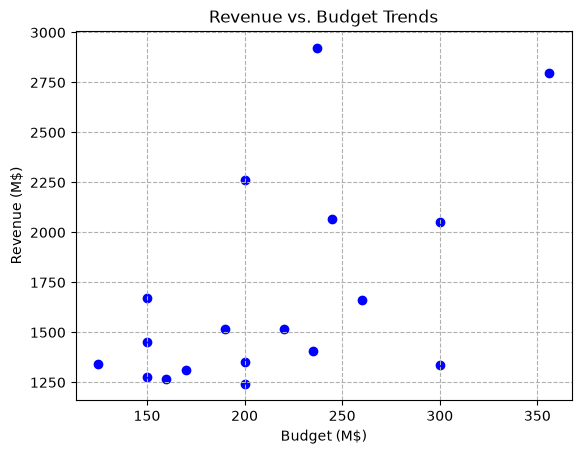

In [60]:
plt.scatter(movies['budget_musd'], movies['revenue_musd'], color='blue')
plt.title('Revenue vs. Budget Trends')
plt.xlabel('Budget (M$)')
plt.ylabel('Revenue (M$)')
plt.grid(True, linestyle='--')

**2. ROI Distribution by Genre**

/tmp/ipykernel_22904/1188116993.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data_to_plot, vert=False, label=genres)


Text(0.5, 0, 'ROI')

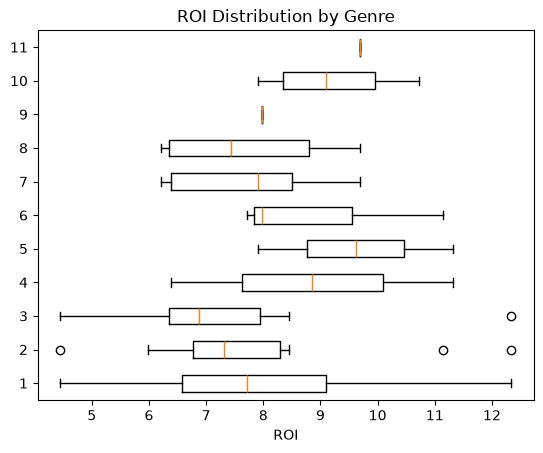

In [ ]:


# Exploding genres to get ROI per specific genre
df_exploded = movies.assign(genres=movies['genres'].str.split('|')).explode('genres')
# Create a list of ROIs per genre for Matplotlib boxplot
genres = df_exploded['genres'].unique()
data_to_plot = [df_exploded[df_exploded['genres'] == g]['roi'].dropna() for g in genres]
plt.boxplot(data_to_plot, vert=False, label=genres)
plt.title('ROI Distribution by Genre')
plt.xlabel('ROI')

**3. Popularity vs. Rating**

Text(0, 0.5, 'Popularity')

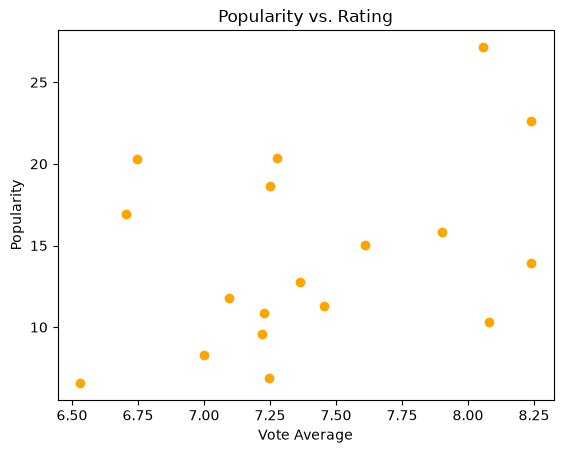

In [61]:

plt.scatter(movies['vote_average'], movies['popularity'], c='orange')
plt.title('Popularity vs. Rating')
plt.xlabel('Vote Average')
plt.ylabel('Popularity')

**4. Yearly Trends in Box Office Performance**

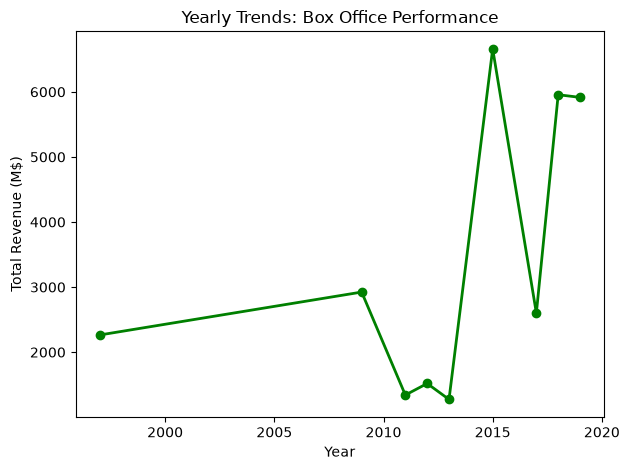

In [ ]:


movies['year'] = movies['release_date'].dt.year
yearly_rev = movies.groupby('year')['revenue_musd'].sum()
plt.plot(yearly_rev.index, yearly_rev.values, marker='o', color='green', linewidth=2)
plt.title('Yearly Trends: Box Office Performance')
plt.xlabel('Year')
plt.ylabel('Total Revenue (M$)')

plt.tight_layout()
plt.show()

**5. Comparison of Franchise vs. Standalone Success**

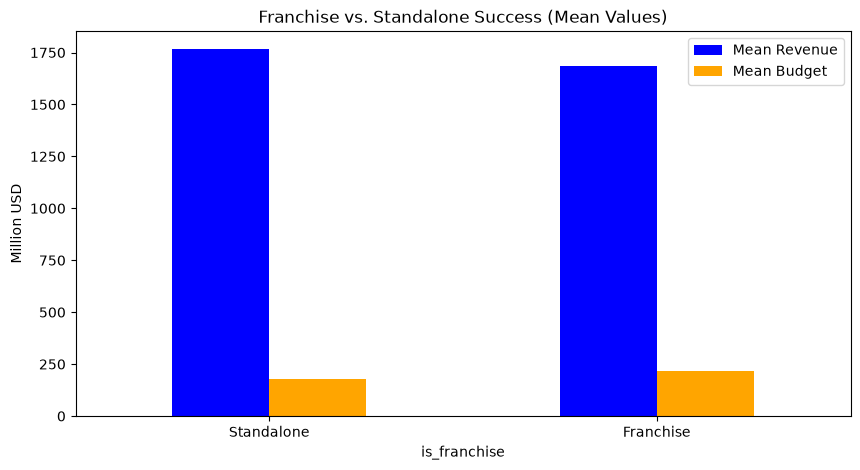

In [ ]:

franchise_summary[['revenue_musd', 'budget_musd']].plot(kind='bar', color=['blue', 'orange'], figsize=(10, 5))
plt.title('Franchise vs. Standalone Success (Mean Values)')
plt.ylabel('Million USD')
plt.xticks([0, 1], ['Standalone', 'Franchise'], rotation=0)
plt.legend(["Mean Revenue", "Mean Budget"])
plt.show()